<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/flyingplanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')

import graphviz

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [51]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [52]:
# Function to convert NLTK tree to graphviz source
def to_graphviz(tree):
    dot = graphviz.Digraph(comment='Parse Tree')

    def add_nodes_edges(tree, dot, parent_index=None, index=0):
        node_index = index
        if isinstance(tree, nltk.Tree):
            node_label = tree.label()
            dot.node(str(node_index), node_label)
            if parent_index is not None:
                dot.edge(str(parent_index), str(node_index))
            for child in tree:
                index += 1
                index = add_nodes_edges(child, dot, node_index, index)
        else:
            # Leaf node
            dot.node(str(index), str(tree))
            if parent_index is not None:
                dot.edge(str(parent_index), str(index))
        return index

    add_nodes_edges(tree, dot)
    return dot


# Convert tree to graphviz source and display



In [144]:
sent='He fed her cat food.'

In [206]:
grammar = """
    NP: {(<PRP>)?<NN.*>|(<JJ>?<NN.*>)}                     # Noun Phrase
    VP: {<VBD>(<PRP>)?<NP>(<NP>)?}                       # Verb Phrase
"""

parser = nltk.RegexpParser(grammar)

In [207]:
#  Tokenizing and tagging
tokens = nltk.word_tokenize(sent)
tagged = nltk.pos_tag(tokens)
print(f'tokens are {tokens}')
print(f'POS tags are {tagged}')

tokens are ['He', 'fed', 'her', 'cat', 'food', '.']
POS tags are [('He', 'PRP'), ('fed', 'VBD'), ('her', 'PRP'), ('cat', 'NN'), ('food', 'NN'), ('.', '.')]


In [208]:
tagged

[('He', 'PRP'),
 ('fed', 'VBD'),
 ('her', 'PRP'),
 ('cat', 'NN'),
 ('food', 'NN'),
 ('.', '.')]

In [209]:
# Create tree
tree = parser.parse(tagged)
print(tree)

(S He/PRP (VP fed/VBD (NP her/PRP cat/NN) (NP food/NN)) ./.)


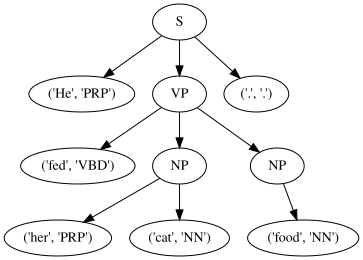

In [210]:
dot_source1 = to_graphviz(tree)
display(dot_source1)

In [211]:
for i in range(len(tagged)):
  if tagged[i][0] == 'cat':
    tagged_alt = tagged.copy()
    tagged_alt[i] = ('cat', 'JJ')

    break

In [212]:
tagged_alt

[('He', 'PRP'),
 ('fed', 'VBD'),
 ('her', 'PRP'),
 ('cat', 'JJ'),
 ('food', 'NN'),
 ('.', '.')]

In [213]:
# Create tree
tree_alt = parser.parse(tagged_alt)
print(tree_alt)

(S He/PRP (VP fed/VBD her/PRP (NP cat/JJ food/NN)) ./.)


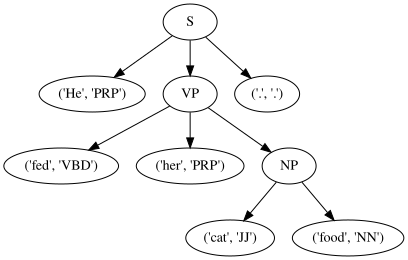

In [214]:
dot_source_alt = to_graphviz(tree_alt)
display(dot_source_alt)

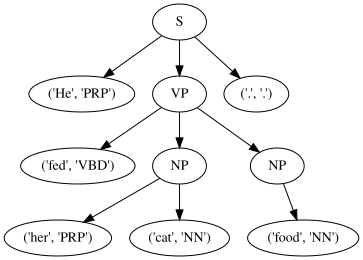

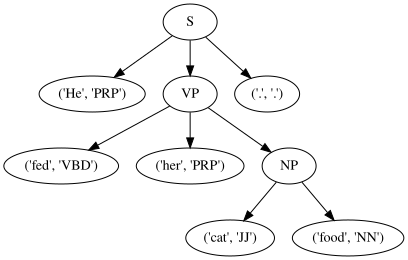

In [215]:
display(dot_source1)
display(dot_source_alt)